# heuristic clustering

The optimal number of clusters was determined using the training set via elbow and silhouette analysis. Cluster stability was subsequently evaluated on the test set. Finally, the clustering model was refit on the full dataset to derive the final interpretable user segments.

In [136]:
# basic modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

# cluster
import hdbscan

# metrics
from sklearn.metrics import silhouette_score

# graphics
import seaborn as sns

pd.set_option('display.float_format', '{:.2f}'.format)

from pathlib import Path


In [117]:
# read data

df = pd.read_pickle("C:/Users/heike/Desktop/Stackfuel/Portfolio/llm-sustainability-analysis/01_data/03_features/conversation_features.pkl")


In [118]:
# orthographic error rate <0.58 for cleaner text

df[df["orthographic_error_rate"]>0.57] # n=53
df=df[df["orthographic_error_rate"]<0.58]
df.shape


(52537, 28)

In [119]:
# features selection
  
FEATURES_SELECTED_v01 = {
    'cat': [
        "task_type",
        "topic_label",
        "prompt_style"        
        ],
    'num': [
        "first_prompt_tokens",
        "log_total_tokens",         # instead total_tokens, total_user_tokens
        "total_turns",                     # no interaction_rounds
        "orthographic_error_rate",
        "question_count"
        ],
    'bin': [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
        "long_context_prompt",
        "has_question"
        ]
}

                         first_prompt_tokens  log_total_tokens  total_turns  \
first_prompt_tokens                     1.00              0.13         0.01   
log_total_tokens                        0.13              1.00         0.56   
total_turns                             0.01              0.56         1.00   
orthographic_error_rate                -0.05              0.06        -0.02   
question_count                          0.40              0.05         0.00   

                         orthographic_error_rate  question_count  
first_prompt_tokens                        -0.05            0.40  
log_total_tokens                            0.06            0.05  
total_turns                                -0.02            0.00  
orthographic_error_rate                     1.00           -0.02  
question_count                             -0.02            1.00  


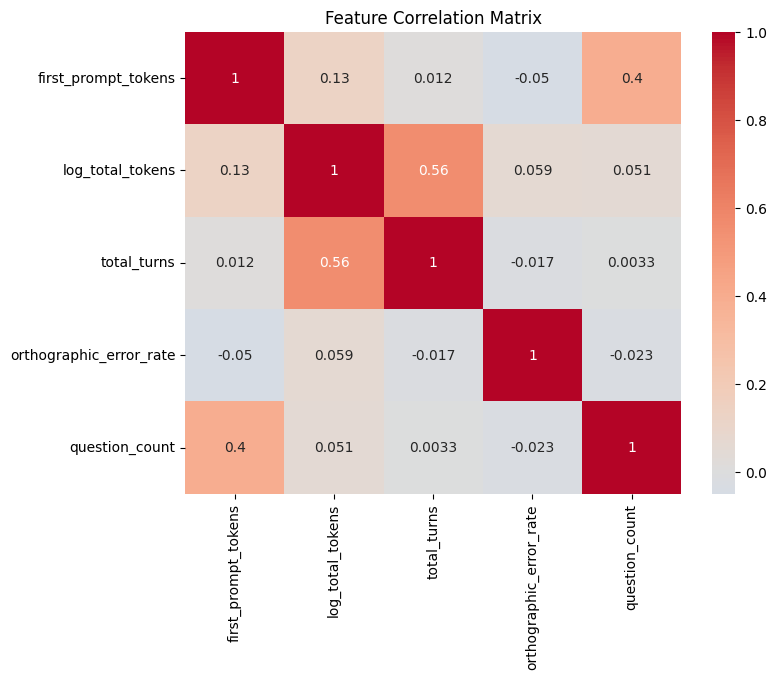

In [120]:
num_features = FEATURES_SELECTED_v01["num"]

corr = features[num_features].corr()

print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

# 1 Heuristic approach with HDBSCAN model

In [121]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), FEATURES_SELECTED_v01['num']),
        ("bin", "passthrough", FEATURES_SELECTED_v01['bin']),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_SELECTED_v01['cat']),
    ],
    remainder="drop"
)

In [122]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,      
    min_samples=10,          
    metric="euclidean",
    cluster_selection_method="eom"
)

# pca
pca = PCA(n_components=10)

pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("pca", pca),
    ("cluster", clusterer)
])


# fit and predict model
labels = pipeline.fit_predict(df)

# labels
df["cluster"] = labels


# results
print(df["cluster"].value_counts())
noise_ratio = (df["cluster"] == -1).mean()
print("Noise ratio:", noise_ratio)



cluster
-1     22750
 30     2229
 29     2224
 25     1686
 33     1585
       ...  
 38       62
 66       60
 34       60
 22       59
 7        52
Name: count, Length: 71, dtype: int64
Noise ratio: 0.43302815158840435


In [123]:
large_clusters = df["cluster"].value_counts()
large_clusters = large_clusters[large_clusters > 1000].index

df["macro_cluster"] = df["cluster"].apply(
    lambda x: x if x in large_clusters else -1)

In [124]:
print("numbers of macro clusters:", len(df["macro_cluster"].value_counts()))

numbers of macro clusters: 9


In [125]:
df["macro_cluster"].value_counts()

macro_cluster
-1     39966
 30     2229
 29     2224
 25     1686
 33     1585
 40     1296
 63     1254
 26     1235
 24     1062
Name: count, dtype: int64

In [126]:
macro_cluster_profile = (
    df.groupby("macro_cluster")
    .agg(
        cluster_size=("macro_cluster", "size"),
        total_tokens_sum=("total_tokens", "sum"),
        total_tokens_mean=("total_tokens", "mean"),
        total_turns=("total_turns", "mean"),
        interaction_rounds=("interaction_rounds", "mean"),
        question_count=("question_count", "mean"),
        orthographic_error_rate=("orthographic_error_rate", "mean"),
        has_role_instruction=("has_role_instruction", "mean"),
        has_format_instruction=("has_format_instruction", "mean"),
        has_long_context=("long_context_prompt", "mean"),
        target_depth_mean=("target_depth", "mean"),
        target_cost_mean=("target_cost", "mean"),
        has_question=("has_question", "mean")
    )
    .round(2)
)

macro_cluster_profile

,cluster_size,total_tokens_sum,total_tokens_mean,total_turns,interaction_rounds,question_count,orthographic_error_rate,has_role_instruction,has_format_instruction,has_long_context,target_depth_mean,target_cost_mean,has_question
macro_cluster,,,,,,,,,,,,,
-1,39966,203194902,5084.19,17.25,8.63,0.59,0.06,0.16,0.31,0.01,2.24,7.56,0.30
24,1062,1102794,1038.41,5.15,2.57,0.00,0.00,0.00,0.00,0.00,1.60,6.57,0.00
25,1686,3642524,2160.45,11.05,5.52,1.04,0.05,0.02,0.05,0.00,2.13,7.03,1.00
26,1235,3565465,2887.02,9.18,4.59,1.03,0.07,0.01,0.07,0.00,2.02,7.44,1.00
29,2224,4296782,1932.01,10.44,5.22,0.00,0.00,0.00,0.00,0.00,2.07,6.94,0.00
30,2229,3035964,1362.03,8.44,4.22,1.00,0.00,0.00,0.00,0.00,1.93,6.63,1.00
33,1585,5882226,3711.18,9.27,4.63,0.00,0.09,0.00,0.00,0.00,2.00,7.60,0.00
40,1296,2165629,1671.01,9.29,4.64,1.08,0.02,0.13,0.00,0.00,1.99,6.86,1.00
63,1254,5521811,4403.36,8.87,4.43,0.00,0.07,0.05,0.00,0.00,2.00,7.88,0.00


In [127]:
pd.crosstab(
    df["macro_cluster"],
    df["task_type"],
    normalize="index"
)

task_type,brainstorming,coding,email_writing,explanation,general_assistance,roleplay,summarization,translation,writing_generation
macro_cluster,,,,,,,,,
-1,0.04,0.20,0.03,0.11,0.33,0.02,0.03,0.02,0.21
24,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
26,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
29,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
30,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
33,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
40,0.28,0.00,0.04,0.52,0.00,0.08,0.03,0.04,0.00
63,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


# typical examples per cluster by probabilities

In [128]:
df["cluster_prob"] = clusterer.probabilities_

In [129]:
def show_typical_prompts_all_clusters(
    df,
    cluster_col="macro_cluster",
    prompt_col="first_prompt",
    prob_col="cluster_prob",
    n=5
):
    """
    Zeigt die typischsten Prompts pro Cluster
    basierend auf HDBSCAN membership probability.
    """

    clusters = sorted(df[cluster_col].unique())

    for cluster_id in clusters:

        print("\n" + "=" * 80)
        print(f"CLUSTER {cluster_id}")
        print("=" * 80)

        subset = (
            df[df[cluster_col] == cluster_id]
            .sort_values(prob_col, ascending=False)
            .head(n)
        )

        for i, (_, row) in enumerate(subset.iterrows(), start=1):

            print(f"\n--- Prompt {i} ---")
            print(f"Task Type: {row['task_type']}")
            print(f"Target Cost: {row['target_cost']:.2f}")
            print(f"Target Depth: {row['target_depth']:.2f}")
            print(f"Cluster Prob: {row[prob_col]:.4f}")

            print("\nFULL PROMPT:")
            print(row[prompt_col])

            print("\n" + "-" * 80)

In [130]:
show_typical_prompts_all_clusters(df, n=10)


CLUSTER -1

--- Prompt 1 ---
Task Type: general_assistance
Target Cost: 8.44
Target Depth: 3.43
Cluster Prob: 1.0000

FULL PROMPT:
I need a report that includes 4 sections for a couple of papers, the sections include:
section 1: Challenges and Issues
section 2: Methodology
section 3: Applications
section 4: Pros and Cons
Note: Each section should be under 30 words
Can you do it?



--------------------------------------------------------------------------------

--- Prompt 2 ---
Task Type: brainstorming
Target Cost: 7.85
Target Depth: 2.56
Cluster Prob: 1.0000

FULL PROMPT:
I want you to become my Prompt Creator. Your goal is to help me craft the best possible prompt for my needs. The prompt will be used by you, ChatGPT. You will follow the following process: 1. Your first response will be to ask me what the prompt should be about. I will provide my answer, but we will need to improve it through continual iterations by going through the next steps. 2. Based on my input, you will gener

In [138]:
base_path = Path(
    "C:/Users/heike/Desktop/Stackfuel/Portfolio/llm-sustainability-analysis/01_data/04_clusters/conversation_features_clusters.csv"
)

base_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(base_path, index=False)

# Insights

- Clustering = diagnosis of structure
- HDBSCAN performs significantly better than K-Means
- A task-dominated island structure was identified
- A large noise cluster is normal and informative
- Prompt-level structure is secondary to task-level structure